# Notebook 13 — Personalization Evaluation

**Purpose:** Unified personalization evaluation across all FSL methods and backbones.

**Personalization = K examples from a test user → adapt → classify remainder.**

**Core metric: Personalization Gain = acc_after − acc_before**

```
acc_before : accuracy WITHOUT any user-specific information (global prototypes)
acc_after  : accuracy WITH K examples from this specific user
gain       : acc_after − acc_before  (can be negative)
```

**Adaptation mechanism per method:**
```
ProtoNet : K-shot prototypes from FSL-trained embedding space (no param update)
LEE      : fine-tune backbone with 3-embedding regularization
MAML     : inner loop gradient steps on meta-learned init
SupCon   : K-shot prototypes from contrastive embedding space (no param update)
```

---
**Requires:** All backbone and FSL checkpoints for the chosen dataset.

## Cell 1 — Setup

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Imports OK
   PyTorch  : 2.10.0+cu128
   NumPy    : 2.0.2
   CUDA     : True
   GPU      : Tesla T4
✅ Seeded everything with MASTER_SEED=42
✅ Global hyperparameters set
   Target frequency : 50 Hz
   Window size      : 250 samples (5.0 sec)
   Window stride    : 125 samples (2.5 sec)
   K shots          : [1, 5, 10]
   N way (default)  : 5
   Embedding dim    : 128
   Device           : cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Paths configured
   Processed data  → /content/drive/MyDrive/fsl_har_processed
   Checkpoints     → /content/drive/MyDrive/fsl_har_checkpoints
   Results         → /content/drive/MyDrive/fsl_har_results
✅ Dataset configs loaded
   wisdm                  →  51 subjects |  18 classes |  4 streams | n_way=5
   cogage_atomic          →   8 subje

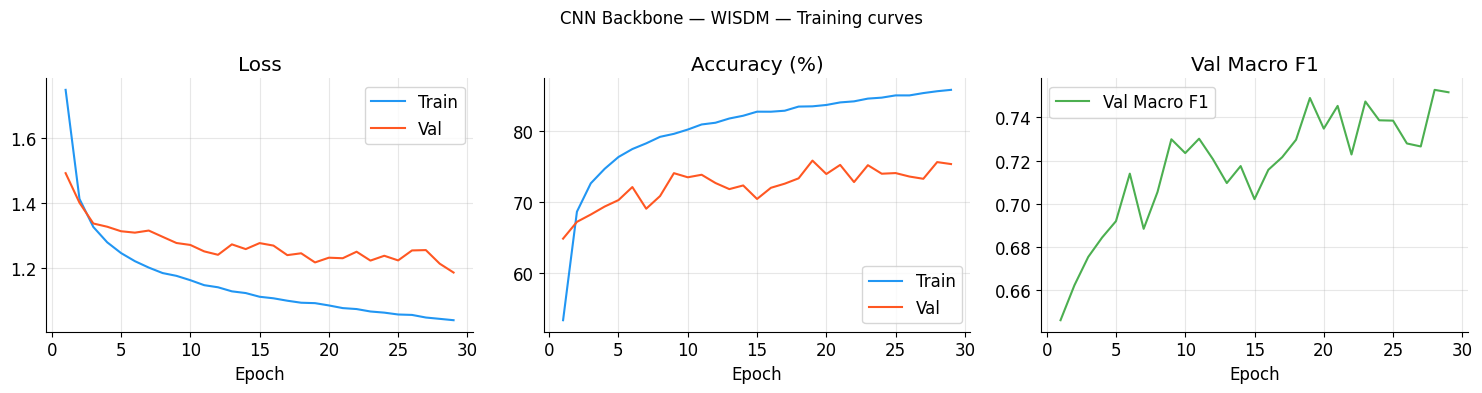

Saved: /content/drive/MyDrive/fsl_har_checkpoints/wisdm/cnn/training_curves.png
Loaded checkpoint from epoch 19
  Checkpoint val acc : 75.78%

── Test set results (unseen users, no adaptation) ──
   Test accuracy  : 69.11%
   Test macro F1  : 0.6766
   Test loss      : 1.3872

   This is the GENERALIZATION baseline.
   FSL methods will improve on this through personalization.

✅ Result saved to registry


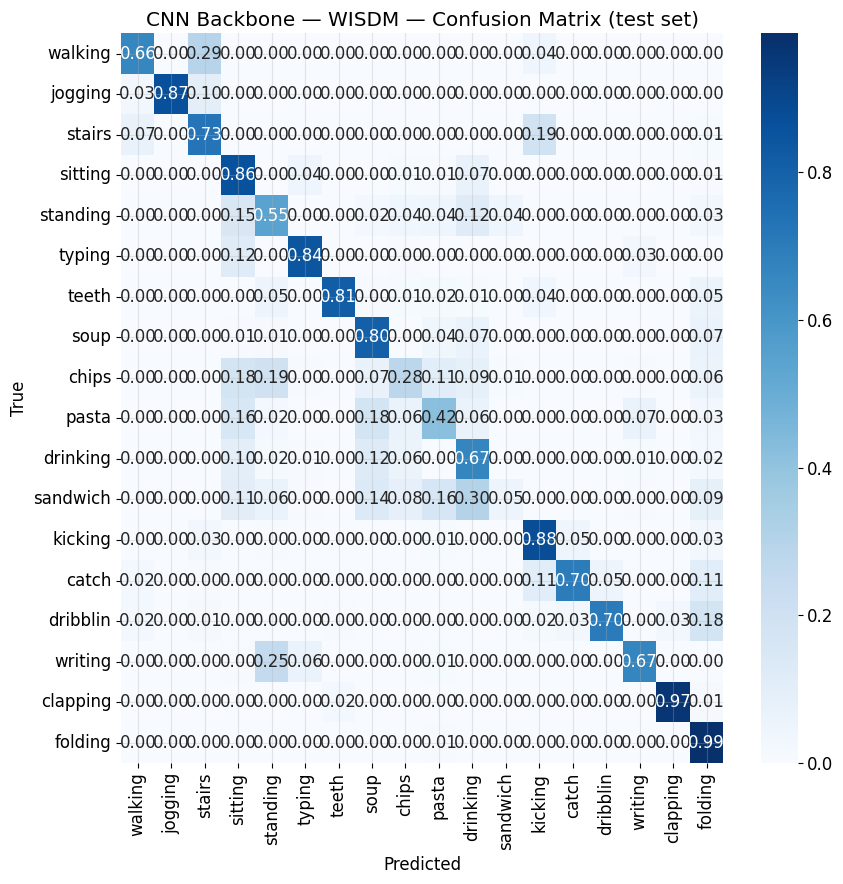

Saved: /content/drive/MyDrive/fsl_har_checkpoints/wisdm/cnn/confusion_matrix.png
Verifying backbone interface for FSL methods...

   n_way=5, k_shot=5
   Support batch size : 25
   Support embeddings : torch.Size([25, 128])
   Expected           : (25, 128)
   Embedding norms    : mean=7.486, std=0.260

✅ Backbone interface verified
   FSL methods can load this backbone with:
   backbone = CNNBackbone(n_streams=4, n_classes=18, ...)
   load_checkpoint(backbone, '/content/drive/MyDrive/fsl_har_checkpoints/wisdm/cnn/best_backbone.pt')
   embeddings = backbone.get_embedding(stream_list)
  CNN BACKBONE TRAINING COMPLETE
  Dataset          : wisdm
  Streams          : 4  (['phone_accel', 'phone_gyro', 'watch_accel', 'watch_gyro'])
  Classes          : 18
  Embedding dim    : 128
  Epochs trained   : 29
  Best val acc     : 75.78%
  Test acc         : 69.11%  ← generalization baseline
  Test macro F1    : 0.6766
  Checkpoint       : /content/drive/MyDrive/fsl_har_checkpoints/wisdm/cnn/best_b

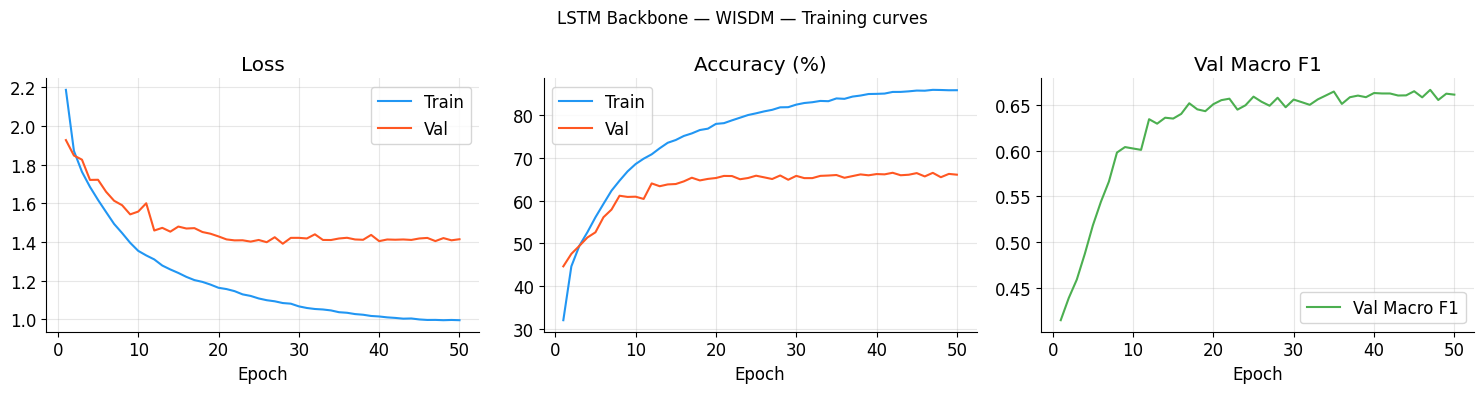

Saved: /content/drive/MyDrive/fsl_har_checkpoints/wisdm/lstm/training_curves.png
Loaded checkpoint from epoch 42

── Test set results ──
   Test accuracy  : 64.92%
   Test macro F1  : 0.6402
   Test loss      : 1.5102

✅ Result saved to registry
── Backbone comparison on wisdm (generalization, no adaptation) ──
Backbone          Test Acc   Macro F1   Best Epoch
──────────────────────────────────────────────────
cnn                 69.11%     0.6766           19
lstm                64.92%     0.6402           42
transformer         65.54%     0.6405            7

Note: full backbone comparison (Phase 3) runs all 3 on same dataset.
Transformer results will appear after notebook 07 is run.
Verifying LSTM backbone FSL interface...

   Support batch      : 25 (5-way × 5-shot)
   Embedding shape    : torch.Size([25, 128])  ✅
   Embedding norms    : mean=7.349, std=0.549

✅ LSTM backbone interface verified — ready for FSL notebooks
  LSTM BACKBONE TRAINING COMPLETE
  Dataset          : wisdm


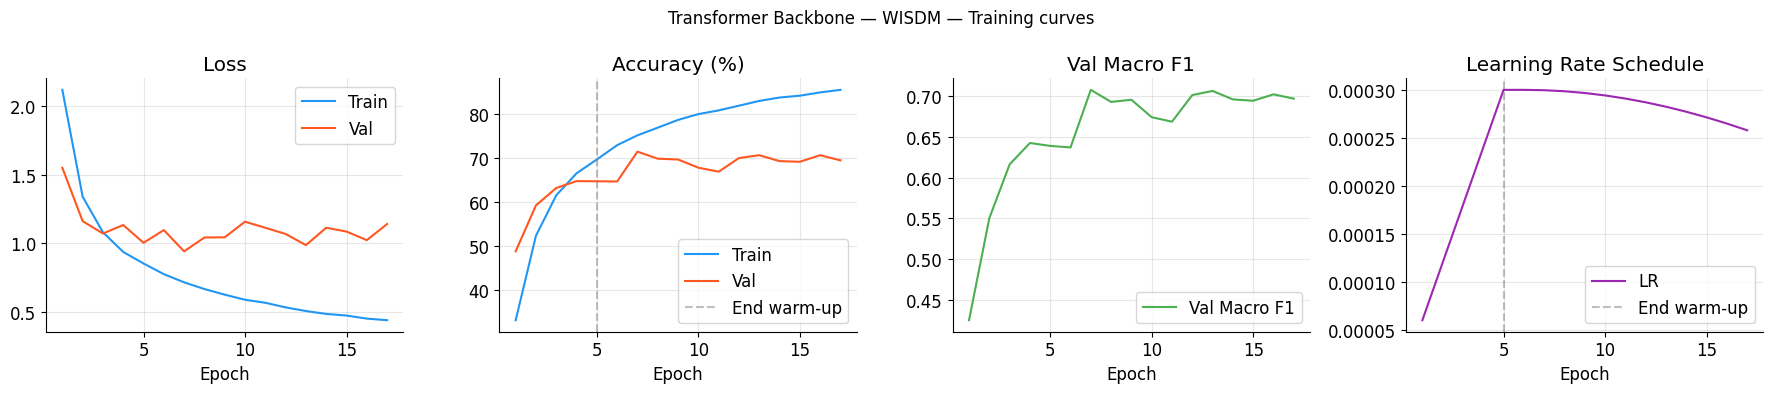

Saved: /content/drive/MyDrive/fsl_har_checkpoints/wisdm/transformer/training_curves.png
Loaded checkpoint from epoch 7

── Test set results ──
   Test accuracy  : 65.54%
   Test macro F1  : 0.6405
   Test loss      : 1.2087

✅ Result saved to registry
── Backbone comparison on WISDM (generalization, no adaptation) ──
Backbone          Test Acc   Macro F1   Best Epoch     Status
────────────────────────────────────────────────────────────
cnn                 69.11%     0.6766           19     ✅ done
lstm                64.92%     0.6402           42     ✅ done
transformer         65.54%     0.6405            7     ✅ done


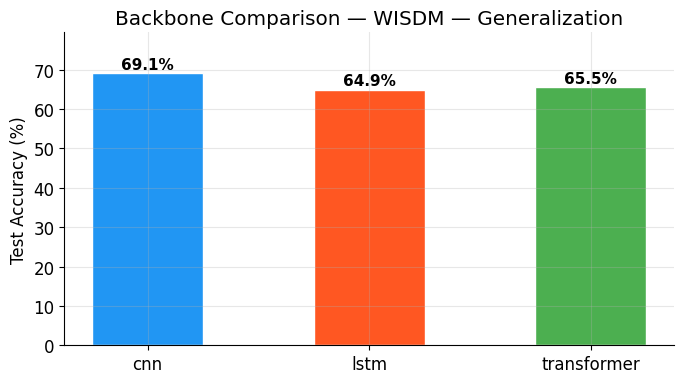


Saved comparison plot: /content/drive/MyDrive/fsl_har_results/backbone_comparison_wisdm.png


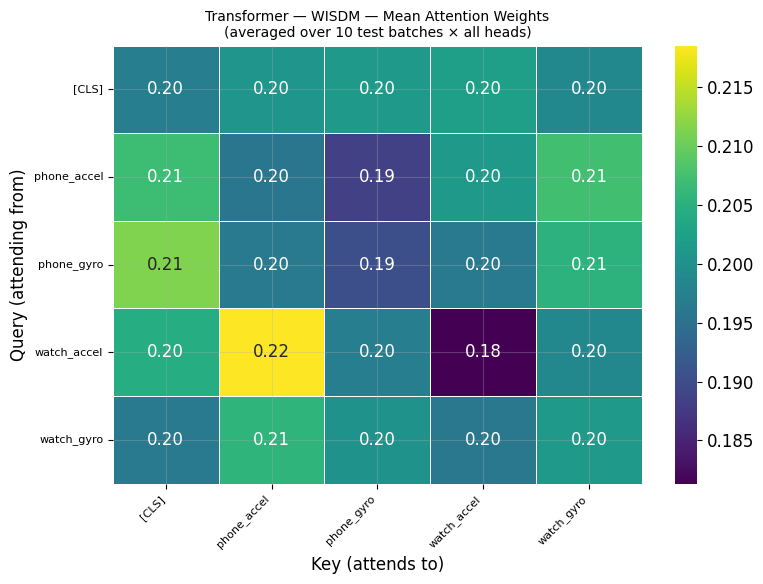

Saved: /content/drive/MyDrive/fsl_har_checkpoints/wisdm/transformer/attention_weights.png

Interpretation guide:
  Row = which token is querying
  Col = which token is being attended to
  [CLS] row shows which sensors the model relies on most for classification
  High diagonal = each sensor mostly self-attends (early training)
  Off-diagonal  = sensors learning from each other (good sign)
Verifying Transformer backbone FSL interface...

   Support batch      : 25 (5-way × 5-shot)
   Embedding shape    : torch.Size([25, 128])  ✅
   Embedding norms    : mean=21.176, std=0.226

✅ Transformer backbone interface verified
   FSL methods use the same get_embedding() call as CNN and LSTM
  TRANSFORMER BACKBONE TRAINING COMPLETE
  Dataset          : wisdm
  Architecture     : Sensor-as-Token Transformer
                     d_model=64, nhead=4, layers=2
  Token sequence   : [CLS] + 4 sensor tokens = 5 total
  Streams          : 4
  Classes          : 18
  Embedding dim    : 128
  Epochs trained

In [7]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

%run "/content/drive/MyDrive/Colab Notebooks/00_config_and_utils.ipynb"
import copy

# ── Backbone class definitions — inline, no %run ──────────────────────────────

class StreamCNNEncoder(nn.Module):
    def __init__(self, in_channels=3, d_stream=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, padding=3),  # 0
            nn.BatchNorm1d(32),                                      # 1
            nn.ReLU(),                                               # 2
            nn.MaxPool1d(kernel_size=2, stride=2),                  # 3
            nn.ReLU(),                                               # 4  ← extra
            nn.Conv1d(32, 64, kernel_size=5, padding=2),            # 5
            nn.BatchNorm1d(64),                                      # 6
            nn.ReLU(),                                               # 7
            nn.MaxPool1d(kernel_size=2, stride=2),                  # 8
            nn.ReLU(),                                               # 9  ← extra
            nn.Conv1d(64, d_stream, kernel_size=3, padding=1),      # 10
            nn.BatchNorm1d(d_stream),                                # 11
            nn.ReLU(),                                               # 12
            nn.AdaptiveAvgPool1d(1),                                 # 13
        )
    def forward(self, x):
        return self.encoder(x.permute(0, 2, 1)).squeeze(-1)


class CNNBackbone(nn.Module):
    def __init__(self, n_streams, n_classes, in_channels=3,
                 d_stream=64, embedding_dim=EMBEDDING_DIM):
        super().__init__()
        self.n_streams     = n_streams
        self.embedding_dim = embedding_dim
        self.stream_encoders = nn.ModuleList([
            StreamCNNEncoder(in_channels, d_stream) for _ in range(n_streams)
        ])
        self.fusion     = nn.Sequential(
            nn.Linear(n_streams * d_stream, embedding_dim), nn.ReLU())
        self.classifier = nn.Linear(embedding_dim, n_classes)
    def forward(self, stream_list, return_embedding=False):
        fused = torch.cat(
            [enc(s) for enc, s in zip(self.stream_encoders, stream_list)],
            dim=-1)
        emb = self.fusion(fused)
        return emb if return_embedding else self.classifier(emb)
    def get_embedding(self, stream_list):
        return self.forward(stream_list, return_embedding=True)


class StreamLSTMEncoder(nn.Module):
    def __init__(self, input_size=3, hidden_size=64,
                 num_layers=2, dropout=0.3):
        super().__init__()
        self.d_stream = hidden_size * 2
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.dropout(out[:, -1, :])


class LSTMBackbone(nn.Module):
    def __init__(self, n_streams, n_classes, input_size=3,
                 hidden_size=64, num_layers=2, dropout=0.3,
                 embedding_dim=EMBEDDING_DIM):
        super().__init__()
        self.n_streams     = n_streams
        self.embedding_dim = embedding_dim
        d_stream           = hidden_size * 2
        self.stream_encoders = nn.ModuleList([
            StreamLSTMEncoder(input_size, hidden_size, num_layers, dropout)
            for _ in range(n_streams)
        ])
        self.fusion = nn.Sequential(
            nn.Linear(n_streams * d_stream, embedding_dim),
            nn.ReLU(), nn.Dropout(0.2))
        self.classifier = nn.Linear(embedding_dim, n_classes)
    def forward(self, stream_list, return_embedding=False):
        fused = torch.cat(
            [enc(s) for enc, s in zip(self.stream_encoders, stream_list)],
            dim=-1)
        emb = self.fusion(fused)
        return emb if return_embedding else self.classifier(emb)
    def get_embedding(self, stream_list):
        return self.forward(stream_list, return_embedding=True)


class StreamTemporalEncoder(nn.Module):
    def __init__(self, in_channels=3, d_model=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(4, 4),
            nn.Conv1d(32, d_model, kernel_size=5, padding=2),
            nn.BatchNorm1d(d_model), nn.ReLU(), nn.AdaptiveAvgPool1d(1),
        )
    def forward(self, x):
        return self.encoder(x.permute(0, 2, 1)).squeeze(-1)


class TransformerBackbone(nn.Module):
    def __init__(self, n_streams, n_classes, in_channels=3,
                 d_model=64, nhead=4, num_layers=2,
                 dim_feedforward=256, dropout=0.1,
                 embedding_dim=EMBEDDING_DIM):
        super().__init__()
        assert d_model % nhead == 0
        self.n_streams     = n_streams
        self.embedding_dim = embedding_dim
        self.stream_encoders = nn.ModuleList([
            StreamTemporalEncoder(in_channels, d_model)
            for _ in range(n_streams)
        ])
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        self.sensor_pos_embedding = nn.Parameter(
            torch.randn(1, n_streams + 1, d_model))
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True, norm_first=True)
        self.transformer_encoder = nn.TransformerEncoder(
            enc_layer, num_layers=num_layers,
            norm=nn.LayerNorm(d_model))
        self.projection = nn.Sequential(
            nn.Linear(d_model, embedding_dim), nn.ReLU())
        self.classifier = nn.Linear(embedding_dim, n_classes)
        self.dropout    = nn.Dropout(dropout)
        self._init_weights()
    def _init_weights(self):
        nn.init.normal_(self.cls_token,            std=0.02)
        nn.init.normal_(self.sensor_pos_embedding, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    def forward(self, stream_list, return_embedding=False):
        b      = stream_list[0].shape[0]
        tokens = torch.stack(
            [enc(s) for enc, s
             in zip(self.stream_encoders, stream_list)], dim=1)
        cls    = self.cls_token.expand(b, -1, -1)
        tokens = torch.cat([cls, tokens], dim=1)                  + self.sensor_pos_embedding
        tokens = self.dropout(tokens)
        enc    = self.transformer_encoder(tokens)
        emb    = self.projection(enc[:, 0, :])
        return emb if return_embedding else self.classifier(emb)
    def get_embedding(self, stream_list):
        return self.forward(stream_list, return_embedding=True)


BACKBONE_CLASSES = {
    'cnn'        : CNNBackbone,
    'lstm'       : LSTMBackbone,
    'transformer': TransformerBackbone,
}

DATASET_NAME = 'wisdm'
N_TRIALS     = 10    # random K-shot splits per user per K

print(f'\n✅ Setup complete')
print(f'   Dataset  : {DATASET_NAME}')
print(f'   K values : {K_SHOTS}')
print(f'   N trials : {N_TRIALS}')
print(f'   Device   : {DEVICE}')


## Cell 2 — Load Dataset

In [8]:
data = load_processed_dataset(DATASET_NAME)

streams      = data['streams']
y            = data['y']
subject_ids  = data['subject_ids']
stream_names = data['stream_names']
split_info   = data['split_info']
cfg          = data['config']

n_streams     = len(stream_names)
n_classes     = cfg['n_classes']
n_way         = cfg['n_way']
N, T, C       = streams[stream_names[0]].shape

# ── Coerce subject IDs to match the type stored in subject_ids array ──────────
# split_info stores subjects as whatever type save_processed_dataset used
# (often int), but when loaded via JSON they become strings.
# subject_ids in the numpy array may be int, str, or object dtype.
# Match them so mask comparisons work correctly.

actual_type = type(subject_ids.flat[0])   # int, str, numpy.int64, etc.

def coerce(s):
    try:
        if actual_type in (int,) or np.issubdtype(type(s), np.integer):
            return int(s)
        return actual_type(s)
    except Exception:
        return s

test_subjects_raw = split_info['test']
train_subjects_raw= split_info['train']

test_subjects  = [coerce(s) for s in test_subjects_raw]
train_subjects = [coerce(s) for s in train_subjects_raw]

train_mask = get_split_mask(subject_ids, train_subjects)
test_mask  = get_split_mask(subject_ids, test_subjects)

print(f'── Dataset: {DATASET_NAME} ──')
print(f'   N={N:,} | streams={n_streams} | classes={n_classes}')
print(f'   Subject ID type in array : {actual_type.__name__}')
print(f'   Test subjects (coerced)  : {test_subjects}')

# ── Build per-user data slices ─────────────────────────────────────────────────
user_data = {}
for subj in test_subjects:
    mask = (subject_ids == subj)
    if mask.sum() == 0:
        print(f'   ⚠ Subject {subj}: 0 windows found — type mismatch still present')
        # Last resort: try string and int versions
        for alt in [str(subj), int(subj) if str(subj).isdigit() else subj]:
            mask = (subject_ids == alt)
            if mask.sum() > 0:
                subj = alt
                print(f'     → Found {mask.sum()} windows using {type(alt).__name__}({alt})')
                break
    if mask.sum() == 0:
        print(f'   ⚠ Subject {subj}: still 0 windows — skipping')
        continue
    user_data[subj] = {
        'streams' : {s: streams[s][mask] for s in stream_names},
        'y'       : y[mask],
        'n'       : int(mask.sum()),
    }
    print(f'   Subject {str(subj):>6}: {mask.sum():>5} windows | '
          f'{len(np.unique(y[mask])):>2} activities')

print(f'\n   Total test users with data: {len(user_data)}')

✅ Loaded "wisdm" — 63513 windows | 4 streams
── Dataset: wisdm ──
   N=63,513 | streams=4 | classes=18
   Subject ID type in array : int
   Test subjects (coerced)  : [1649, 1602, 1636, 1633, 1601, 1613, 1608]
   Subject   1649:  1284 windows | 18 activities
   Subject   1602:  1260 windows | 18 activities
   Subject   1636:  1260 windows | 18 activities
   Subject   1633:  1260 windows | 18 activities
   Subject   1601:  1278 windows | 18 activities
   Subject   1613:  1278 windows | 18 activities
   Subject   1608:  1260 windows | 18 activities

   Total test users with data: 7


## Cell 3 — Backbone Infrastructure

In [9]:
BACKBONE_KWARGS = {
    'cnn': dict(
        n_streams=n_streams, n_classes=n_classes,
        in_channels=C, d_stream=64, embedding_dim=EMBEDDING_DIM
    ),
    'lstm': dict(
        n_streams=n_streams, n_classes=n_classes,
        input_size=C, hidden_size=64, num_layers=2,
        dropout=0.3, embedding_dim=EMBEDDING_DIM
    ),
    'transformer': dict(
        n_streams=n_streams, n_classes=n_classes,
        in_channels=C, d_model=64, nhead=4, num_layers=2,
        dim_feedforward=256, dropout=0.1, embedding_dim=EMBEDDING_DIM
    ),
}

BACKBONE_CLASSES = {
    'cnn': CNNBackbone,
    'lstm': LSTMBackbone,
    'transformer': TransformerBackbone,
}

CKPT_FILENAMES = {
    'pretrain': 'best_backbone.pt',
    'protonet': 'protonet/best_protonet.pt',
    'lee': 'best_backbone.pt',
    'maml': 'maml/best_maml.pt',
    'supcon': 'supcon/best_supcon.pt',
}


def load_backbone(backbone_type: str, method: str) -> Optional[nn.Module]:
    ckpt_path = os.path.join(
        CHECKPOINT_BASE,
        DATASET_NAME,
        backbone_type,
        CKPT_FILENAMES[method]
    )

    if not os.path.exists(ckpt_path):
        return None

    cls   = BACKBONE_CLASSES[backbone_type]
    model = cls(**BACKBONE_KWARGS[backbone_type]).to(DEVICE)

    load_checkpoint(model, ckpt_path)
    model.eval()
    return model


print('✅ Backbone infrastructure ready')

✅ Backbone infrastructure ready


## Cell 4 — Universal Global Prototype Baseline

In [10]:
@torch.no_grad()
def build_global_prototypes(backbone: nn.Module, batch_size: int = 256) -> torch.Tensor:
    """Build global class prototypes from ALL train user embeddings."""
    backbone.eval()

    proto_sums   = torch.zeros(n_classes, EMBEDDING_DIM, device=DEVICE)
    proto_counts = torch.zeros(n_classes, device=DEVICE)

    indices = np.where(train_mask)[0]

    for start in range(0, len(indices), batch_size):
        batch_idx = indices[start:start + batch_size]

        stream_list = [
            torch.tensor(streams[s][batch_idx], dtype=torch.float32).to(DEVICE)
            for s in stream_names
        ]

        emb    = backbone.get_embedding(stream_list)
        labels = torch.tensor(y[batch_idx], dtype=torch.long).to(DEVICE)

        for c in range(n_classes):
            mask = (labels == c)
            if mask.any():
                proto_sums[c]   += emb[mask].sum(dim=0)
                proto_counts[c] += mask.sum()

    valid = proto_counts > 0
    gp    = torch.zeros_like(proto_sums)
    gp[valid] = proto_sums[valid] / proto_counts[valid].unsqueeze(-1)

    return gp

## Cell 5 — Per-Method Personalization Functions

In [11]:
@torch.no_grad()
def personalize_protonet(backbone, user_streams, user_y,
                         support_idx, query_idx, class_to_rel):
    """ProtoNet/SupCon: K-shot nearest-prototype (no parameter update)."""

    n_ep_way = len(class_to_rel)

    sup_list = [
        torch.tensor(user_streams[s][support_idx], dtype=torch.float32).to(DEVICE)
        for s in stream_names
    ]
    qry_list = [
        torch.tensor(user_streams[s][query_idx], dtype=torch.float32).to(DEVICE)
        for s in stream_names
    ]

    sup_labels_rel = torch.tensor(
        [class_to_rel[user_y[i]] for i in support_idx],
        dtype=torch.long
    ).to(DEVICE)

    qry_labels_rel = torch.tensor(
        [class_to_rel[user_y[i]] for i in query_idx],
        dtype=torch.long
    ).to(DEVICE)

    sup_emb = backbone.get_embedding(sup_list)
    qry_emb = backbone.get_embedding(qry_list)

    protos = torch.zeros(n_ep_way, EMBEDDING_DIM, device=DEVICE)
    for c in range(n_ep_way):
        mask = (sup_labels_rel == c)
        if mask.any():
            protos[c] = sup_emb[mask].mean(dim=0)

    diff  = qry_emb.unsqueeze(1) - protos.unsqueeze(0)
    preds = (diff ** 2).sum(dim=-1).argmin(dim=-1)

    return (preds == qry_labels_rel).float().mean().item()


def personalize_lee(backbone_pretrained, user_streams, user_y,
                    support_idx, query_idx, class_to_rel):
    """LEE: 3-embedding regularized fine-tuning."""

    n_ep_way = len(class_to_rel)

    sup_list = [
        torch.tensor(user_streams[s][support_idx], dtype=torch.float32).to(DEVICE)
        for s in stream_names
    ]
    qry_list = [
        torch.tensor(user_streams[s][query_idx], dtype=torch.float32).to(DEVICE)
        for s in stream_names
    ]

    sup_labels_rel = torch.tensor(
        [class_to_rel[user_y[i]] for i in support_idx],
        dtype=torch.long
    ).to(DEVICE)

    qry_labels_rel = torch.tensor(
        [class_to_rel[user_y[i]] for i in query_idx],
        dtype=torch.long
    ).to(DEVICE)

    with torch.no_grad():
        e_control = backbone_pretrained.get_embedding(sup_list).detach()

    adapting = copy.deepcopy(backbone_pretrained).to(DEVICE)
    adapting.train()

    for p in adapting.parameters():
        p.requires_grad = True

    with torch.no_grad():
        e_fixed = adapting.get_embedding(sup_list).detach()

    optimizer = torch.optim.Adam(
        adapting.parameters(),
        lr=LEE_FINETUNE_LR,
        weight_decay=1e-5
    )

    for _ in range(LEE_FINETUNE_EPOCHS):
        adapting.train()
        optimizer.zero_grad()

        e_cur = adapting.get_embedding(sup_list)

        protos = torch.zeros(n_ep_way, EMBEDDING_DIM, device=DEVICE)
        for c in range(n_ep_way):
            mask = (sup_labels_rel == c)
            if mask.any():
                protos[c] = e_cur[mask].mean(dim=0)

        loss_task = nn.functional.cross_entropy(
            -((e_cur.unsqueeze(1) - protos.unsqueeze(0)) ** 2).sum(-1),
            sup_labels_rel
        )

        e_n  = nn.functional.normalize(e_cur, dim=-1)
        ec_n = nn.functional.normalize(e_control, dim=-1)
        ef_n = nn.functional.normalize(e_fixed, dim=-1)

        loss_reg = (
            (1 - (e_n * ec_n).sum(-1)).mean() +
            (1 - (e_n * ef_n).sum(-1)).mean()
        )

        (loss_task + LEE_LAMBDA * loss_reg).backward()

        torch.nn.utils.clip_grad_norm_(adapting.parameters(), 1.0)
        optimizer.step()

    adapting.eval()

    with torch.no_grad():
        e_f = adapting.get_embedding(sup_list)

        pf = torch.zeros(n_ep_way, EMBEDDING_DIM, device=DEVICE)
        for c in range(n_ep_way):
            mask = (sup_labels_rel == c)
            if mask.any():
                pf[c] = e_f[mask].mean(dim=0)

        qry_emb = adapting.get_embedding(qry_list)

        diff  = qry_emb.unsqueeze(1) - pf.unsqueeze(0)
        preds = (diff ** 2).sum(-1).argmin(-1)

        acc = (preds == qry_labels_rel).float().mean().item()

    del adapting, optimizer
    return acc


def personalize_maml(meta_model, user_streams, user_y,
                     support_idx, query_idx, class_to_rel):
    """MAML: inner loop adaptation."""

    n_ep_way = len(class_to_rel)

    sup_list = [
        torch.tensor(user_streams[s][support_idx], dtype=torch.float32).to(DEVICE)
        for s in stream_names
    ]
    qry_list = [
        torch.tensor(user_streams[s][query_idx], dtype=torch.float32).to(DEVICE)
        for s in stream_names
    ]

    sup_labels_rel = torch.tensor(
        [class_to_rel[user_y[i]] for i in support_idx],
        dtype=torch.long
    ).to(DEVICE)

    qry_labels_rel = torch.tensor(
        [class_to_rel[user_y[i]] for i in query_idx],
        dtype=torch.long
    ).to(DEVICE)

    adapted = copy.deepcopy(meta_model).to(DEVICE)
    adapted.train()

    inner_opt = torch.optim.SGD(adapted.parameters(), lr=MAML_INNER_LR)

    for _ in range(MAML_INNER_STEPS):
        inner_opt.zero_grad()

        emb = adapted.get_embedding(sup_list)

        protos = torch.zeros(n_ep_way, EMBEDDING_DIM, device=DEVICE)
        for c in range(n_ep_way):
            mask = (sup_labels_rel == c)
            if mask.any():
                protos[c] = emb[mask].mean(dim=0)

        loss = nn.functional.cross_entropy(
            -((emb.unsqueeze(1) - protos.unsqueeze(0)) ** 2).sum(-1),
            sup_labels_rel
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(adapted.parameters(), 1.0)
        inner_opt.step()

    adapted.eval()

    with torch.no_grad():
        sup_emb = adapted.get_embedding(sup_list)

        pf = torch.zeros(n_ep_way, EMBEDDING_DIM, device=DEVICE)
        for c in range(n_ep_way):
            mask = (sup_labels_rel == c)
            if mask.any():
                pf[c] = sup_emb[mask].mean(dim=0)

        qry_emb = adapted.get_embedding(qry_list)

        diff  = qry_emb.unsqueeze(1) - pf.unsqueeze(0)
        preds = (diff ** 2).sum(-1).argmin(-1)

        acc = (preds == qry_labels_rel).float().mean().item()

    del adapted, inner_opt
    return acc


PERSONALIZE_FN = {
    'protonet': personalize_protonet,
    'lee': personalize_lee,
    'maml': personalize_maml,
    'supcon': personalize_protonet,  # same mechanism, different backbone
}

print('✅ Per-method personalization functions defined')

✅ Per-method personalization functions defined


## Cell 6 — Main Personalization Loop

In [12]:
# ── All helper functions inlined to guarantee scope ───────────────────────────

def split_user_data(user_y, k_shot, rng):
    classes       = np.unique(user_y)
    valid_classes = [c for c in classes if (user_y == c).sum() > k_shot]
    if len(valid_classes) < 2:
        return None
    support_idx, query_idx = [], []
    for c in valid_classes:
        c_idx = np.where(user_y == c)[0].copy()
        rng.shuffle(c_idx)
        support_idx.extend(c_idx[:k_shot].tolist())
        query_idx.extend(c_idx[k_shot:].tolist())
    if not query_idx:
        return None
    return valid_classes, support_idx, query_idx, {c: i for i, c in enumerate(valid_classes)}


@torch.no_grad()
def build_global_prototypes(backbone, batch_size=256):
    backbone.eval()
    proto_sums   = torch.zeros(n_classes, EMBEDDING_DIM, device=DEVICE)
    proto_counts = torch.zeros(n_classes, device=DEVICE)
    indices = np.where(train_mask)[0]
    for start in range(0, len(indices), batch_size):
        batch_idx   = indices[start:start + batch_size]
        stream_list = [
            torch.tensor(streams[s][batch_idx], dtype=torch.float32).to(DEVICE)
            for s in stream_names
        ]
        emb    = backbone.get_embedding(stream_list)
        labels = torch.tensor(y[batch_idx], dtype=torch.long).to(DEVICE)
        for c in range(n_classes):
            mask = (labels == c)
            if mask.any():
                proto_sums[c]   += emb[mask].sum(0)
                proto_counts[c] += mask.sum()
    valid = proto_counts > 0
    gp    = torch.zeros_like(proto_sums)
    gp[valid] = proto_sums[valid] / proto_counts[valid].unsqueeze(-1)
    return gp


@torch.no_grad()
def acc_before_for_user(backbone, global_protos, user_streams,
                        user_y, valid_classes, query_idx, class_to_rel):
    # Batched query embedding to prevent CUDA OOM on sequence models like LSTM
    infer_batch = 128
    qry_embs = []
    for b_start in range(0, len(query_idx), infer_batch):
        b_end = min(b_start + infer_batch, len(query_idx))
        b_idx = query_idx[b_start:b_end]
        qb_l  = [torch.tensor(user_streams[s][b_idx], dtype=torch.float32).to(DEVICE) for s in stream_names]
        qry_embs.append(backbone.get_embedding(qb_l))
    qry_emb = torch.cat(qry_embs, dim=0)

    qry_labels_rel = torch.tensor(
        [class_to_rel[user_y[i]] for i in query_idx], dtype=torch.long
    ).to(DEVICE)
    valid_protos = global_protos[list(valid_classes)]
    diff         = qry_emb.unsqueeze(1) - valid_protos.unsqueeze(0)
    preds        = (diff ** 2).sum(dim=-1).argmin(dim=-1)
    return (preds == qry_labels_rel).float().mean().item()


# ── Personalize functions (inlined from Cell 5) ───────────────────────────────

@torch.no_grad()
def personalize_protonet(backbone, user_streams, user_y,
                         support_idx, query_idx, class_to_rel):
    n_ep_way       = len(class_to_rel)
    sup_list       = [torch.tensor(user_streams[s][support_idx], dtype=torch.float32).to(DEVICE) for s in stream_names]
    sup_labels_rel = torch.tensor([class_to_rel[user_y[i]] for i in support_idx], dtype=torch.long).to(DEVICE)
    qry_labels_rel = torch.tensor([class_to_rel[user_y[i]] for i in query_idx],   dtype=torch.long).to(DEVICE)
    
    # Support size is very small, no batching needed
    sup_emb = backbone.get_embedding(sup_list)
    
    # Query embedding (batched to prevent CUDA OOM)
    infer_batch = 128
    qry_embs = []
    for b_start in range(0, len(query_idx), infer_batch):
        b_end = min(b_start + infer_batch, len(query_idx))
        b_idx = query_idx[b_start:b_end]
        qb_l  = [torch.tensor(user_streams[s][b_idx], dtype=torch.float32).to(DEVICE) for s in stream_names]
        qry_embs.append(backbone.get_embedding(qb_l))
    qry_emb = torch.cat(qry_embs, dim=0)

    protos  = torch.zeros(n_ep_way, EMBEDDING_DIM, device=DEVICE)
    for c in range(n_ep_way):
        mask = (sup_labels_rel == c)
        if mask.any():
            protos[c] = sup_emb[mask].mean(0)
    diff  = qry_emb.unsqueeze(1) - protos.unsqueeze(0)
    preds = (diff ** 2).sum(dim=-1).argmin(dim=-1)
    return (preds == qry_labels_rel).float().mean().item()


def personalize_lee(backbone_pretrained, user_streams, user_y,
                    support_idx, query_idx, class_to_rel):
    import copy
    n_ep_way       = len(class_to_rel)
    sup_list       = [torch.tensor(user_streams[s][support_idx], dtype=torch.float32).to(DEVICE) for s in stream_names]
    sup_labels_rel = torch.tensor([class_to_rel[user_y[i]] for i in support_idx], dtype=torch.long).to(DEVICE)
    qry_labels_rel = torch.tensor([class_to_rel[user_y[i]] for i in query_idx],   dtype=torch.long).to(DEVICE)
    
    with torch.no_grad():
        e_control = backbone_pretrained.get_embedding(sup_list).detach()
    adapting = copy.deepcopy(backbone_pretrained).to(DEVICE)
    adapting.train()
    for p in adapting.parameters(): p.requires_grad = True
    with torch.no_grad():
        e_fixed = adapting.get_embedding(sup_list).detach()
    
    optimizer = torch.optim.Adam(adapting.parameters(), lr=LEE_FINETUNE_LR, weight_decay=1e-5)
    for _ in range(LEE_FINETUNE_EPOCHS):
        adapting.train(); optimizer.zero_grad()
        e_cur  = adapting.get_embedding(sup_list)
        protos = torch.zeros(n_ep_way, EMBEDDING_DIM, device=DEVICE)
        for c in range(n_ep_way):
            mask = (sup_labels_rel == c)
            if mask.any(): protos[c] = e_cur[mask].mean(0)
        loss_task = nn.functional.cross_entropy(
            -((e_cur.unsqueeze(1) - protos.unsqueeze(0))**2).sum(-1), sup_labels_rel)
        en  = nn.functional.normalize(e_cur,     dim=-1)
        ecn = nn.functional.normalize(e_control, dim=-1)
        efn = nn.functional.normalize(e_fixed,   dim=-1)
        loss_reg = (1-(en*ecn).sum(-1)).mean() + (1-(en*efn).sum(-1)).mean()
        (loss_task + LEE_LAMBDA * loss_reg).backward()
        torch.nn.utils.clip_grad_norm_(adapting.parameters(), 1.0)
        optimizer.step()
        
    adapting.eval()
    with torch.no_grad():
        ef2 = adapting.get_embedding(sup_list)
        pf  = torch.zeros(n_ep_way, EMBEDDING_DIM, device=DEVICE)
        for c in range(n_ep_way):
            mask = (sup_labels_rel == c)
            if mask.any(): pf[c] = ef2[mask].mean(0)
            
        # Query embedding (batched to prevent CUDA OOM)
        infer_batch = 128
        qry_embs = []
        for b_start in range(0, len(query_idx), infer_batch):
            b_end = min(b_start + infer_batch, len(query_idx))
            b_idx = query_idx[b_start:b_end]
            qb_l  = [torch.tensor(user_streams[s][b_idx], dtype=torch.float32).to(DEVICE) for s in stream_names]
            qry_embs.append(adapting.get_embedding(qb_l))
        qry_emb = torch.cat(qry_embs, dim=0)

        diff    = qry_emb.unsqueeze(1) - pf.unsqueeze(0)
        preds   = (diff**2).sum(-1).argmin(-1)
        acc     = (preds == qry_labels_rel).float().mean().item()
    del adapting, optimizer
    return acc


def personalize_maml(meta_model, user_streams, user_y,
                     support_idx, query_idx, class_to_rel):
    import copy
    n_ep_way       = len(class_to_rel)
    sup_list       = [torch.tensor(user_streams[s][support_idx], dtype=torch.float32).to(DEVICE) for s in stream_names]
    sup_labels_rel = torch.tensor([class_to_rel[user_y[i]] for i in support_idx], dtype=torch.long).to(DEVICE)
    qry_labels_rel = torch.tensor([class_to_rel[user_y[i]] for i in query_idx],   dtype=torch.long).to(DEVICE)
    
    adapted   = copy.deepcopy(meta_model).to(DEVICE)
    adapted.train()
    inner_opt = torch.optim.SGD(adapted.parameters(), lr=MAML_INNER_LR)
    for _ in range(MAML_INNER_STEPS):
        inner_opt.zero_grad()
        emb    = adapted.get_embedding(sup_list)
        protos = torch.zeros(n_ep_way, EMBEDDING_DIM, device=DEVICE)
        for c in range(n_ep_way):
            mask = (sup_labels_rel == c)
            if mask.any(): protos[c] = emb[mask].mean(0)
        loss = nn.functional.cross_entropy(
            -((emb.unsqueeze(1) - protos.unsqueeze(0))**2).sum(-1), sup_labels_rel)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(adapted.parameters(), 1.0)
        inner_opt.step()
        
    adapted.eval()
    with torch.no_grad():
        sup_emb = adapted.get_embedding(sup_list)
        pf      = torch.zeros(n_ep_way, EMBEDDING_DIM, device=DEVICE)
        for c in range(n_ep_way):
            mask = (sup_labels_rel == c)
            if mask.any(): pf[c] = sup_emb[mask].mean(0)
            
        # Query embedding (batched to prevent CUDA OOM)
        infer_batch = 128
        qry_embs = []
        for b_start in range(0, len(query_idx), infer_batch):
            b_end = min(b_start + infer_batch, len(query_idx))
            b_idx = query_idx[b_start:b_end]
            qb_l  = [torch.tensor(user_streams[s][b_idx], dtype=torch.float32).to(DEVICE) for s in stream_names]
            qry_embs.append(adapted.get_embedding(qb_l))
        qry_emb = torch.cat(qry_embs, dim=0)

        diff    = qry_emb.unsqueeze(1) - pf.unsqueeze(0)
        preds   = (diff**2).sum(-1).argmin(-1)
        acc     = (preds == qry_labels_rel).float().mean().item()
    del adapted, inner_opt
    return acc


# We keep PERSONALIZE_FN mapping
PERSONALIZE_FN = {
    'protonet': personalize_protonet,
    'lee'     : personalize_lee,
    'maml'    : personalize_maml,
    'supcon'  : personalize_protonet,   # same mechanism, different backbone
}

# ── Main loop ─────────────────────────────────────────────────────────────────
results_pers = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
results_csv  = os.path.join(RESULTS_BASE, f'personalization_{DATASET_NAME}.csv')

# Clean old CSV to prevent duplicate accumulation
if os.path.exists(results_csv):
    try:
        os.remove(results_csv)
        print(f"🗑 Deleted old personalization CSV to prevent duplicates: {results_csv}")
    except Exception as e:
        print(f"⚠️ Could not delete old CSV (might be open in another app): {e}")

print(f'Personalization evaluation: {DATASET_NAME}')
print(f'Users: {list(user_data.keys())} | K: {K_SHOTS} | Trials: {N_TRIALS}')
print(f'{"─"*65}\n')

for backbone_type in ALL_BACKBONES:
    for method in ALL_FSL_METHODS:
        print(f'── {backbone_type.upper()} × {method} ──')

        backbone = load_backbone(backbone_type, method)
        if backbone is None:
            print(f'   ❌ Checkpoint not found — skipping\n')
            continue

        global_protos = build_global_prototypes(backbone)
        n_valid = (global_protos.norm(dim=-1) > 0).sum().item()
        print(f'   Global prototypes: {n_valid}/{n_classes} classes')

        for k in K_SHOTS:
            user_rows = []

            for subj, udata in user_data.items():
                rng       = np.random.default_rng(MASTER_SEED)
                trial_bef = []
                trial_aft = []

                for _ in range(N_TRIALS):
                    split = split_user_data(udata['y'], k, rng)
                    if split is None:
                        break
                    valid_classes, sup_idx, qry_idx, c2r = split

                    ab = acc_before_for_user(
                        backbone, global_protos,
                        udata['streams'], udata['y'],
                        valid_classes, qry_idx, c2r
                    )
                    fn = PERSONALIZE_FN[method]
                    aa = fn(backbone, udata['streams'], udata['y'],
                            sup_idx, qry_idx, c2r)
                    trial_bef.append(ab)
                    trial_aft.append(aa)

                if not trial_aft:
                    continue

                ab_mean = float(np.mean(trial_bef))
                aa_mean = float(np.mean(trial_aft))
                gain    = compute_personalization_gain(ab_mean, aa_mean)

                row = {
                    'dataset'   : DATASET_NAME,
                    'backbone'  : backbone_type,
                    'method'    : method,
                    'k_shot'    : k,
                    'subject'   : str(subj),
                    'acc_before': ab_mean,
                    'acc_after' : aa_mean,
                    'gain'      : gain,
                    'ci95'      : None,
                }
                user_rows.append(row)
                results_pers[backbone_type][method][k].append(row)
                append_pers_results(row, results_csv)

            if user_rows:
                mg = np.mean([r['gain']       for r in user_rows])
                mb = np.mean([r['acc_before'] for r in user_rows])
                ma = np.mean([r['acc_after']  for r in user_rows])
                print(f'   K={k}: before={mb*100:.1f}% after={ma*100:.1f}% '
                      f'gain={mg*100:+.2f}% ({len(user_rows)} users)')

        del backbone


Personalization evaluation: wisdm
Users: [1649, 1602, 1636, 1633, 1601, 1613, 1608] | K: [1, 5, 10] | Trials: 10
─────────────────────────────────────────────────────────────────

── CNN × protonet ──
   Global prototypes: 18/18 classes
   K=1: before=68.8% after=86.6% gain=+17.80% (7 users)
   K=5: before=68.7% after=92.9% gain=+24.14% (7 users)
   K=10: before=68.7% after=93.5% gain=+24.80% (7 users)

── CNN × lee ──
   Global prototypes: 18/18 classes
   K=1: before=69.9% after=86.8% gain=+16.85% (7 users)
   K=5: before=69.9% after=93.1% gain=+23.17% (7 users)
   K=10: before=70.0% after=94.3% gain=+24.29% (7 users)

── CNN × maml ──
   Global prototypes: 18/18 classes
   K=1: before=64.4% after=89.4% gain=+25.03% (7 users)
   K=5: before=64.4% after=94.9% gain=+30.48% (7 users)
   K=10: before=64.4% after=95.5% gain=+31.15% (7 users)

── CNN × supcon ──
   Global prototypes: 18/18 classes
   K=1: before=67.5% after=85.3% gain=+17.76% (7 users)
   K=5: before=67.5% after=91.6% gain

## Cell 7 — Main Results Table

In [13]:
k_focus = max(K_SHOTS)

print(f'══ Personalization Gain — {DATASET_NAME.upper()} (K={k_focus}-shot) ══')
print(f'   Gain = acc_after − acc_before')
print()

avail_bb = [b for b in ALL_BACKBONES if b in results_pers]

print(f'{"Method":<15}', end='')
for bb in avail_bb:
    print(f'{bb.upper():>20}', end='')
print()

print('─' * (15 + 20 * len(avail_bb)))

for method in ALL_FSL_METHODS:
    print(f'{method:<15}', end='')

    for bb in avail_bb:
        rows = results_pers[bb][method][k_focus]

        if not rows:
            print(f'{"—":>20}', end='')
            continue

        gains = [r['gain'] for r in rows]
        ci95  = 1.96 * np.std(gains) / np.sqrt(len(gains))

        val = f'{np.mean(gains)*100:+.1f}±{ci95*100:.1f}%'
        print(f'{val:>20}', end='')

    print()

print()
print('Format: mean_gain% ± CI95%  (+ = K-shot helped)')

══ Personalization Gain — WISDM (K=10-shot) ══
   Gain = acc_after − acc_before

Method                          CNN                LSTM         TRANSFORMER
───────────────────────────────────────────────────────────────────────────
protonet                 +24.8±8.8%          +27.5±8.8%          +22.6±8.5%
lee                      +24.3±7.5%          +27.5±9.5%          +23.8±8.5%
maml                     +31.1±9.1%          +28.8±8.8%         +35.8±12.2%
supcon                   +25.0±8.0%          +25.5±9.9%          +18.9±6.9%

Format: mean_gain% ± CI95%  (+ = K-shot helped)


## Cell 8 — K-Shot Gain Curves

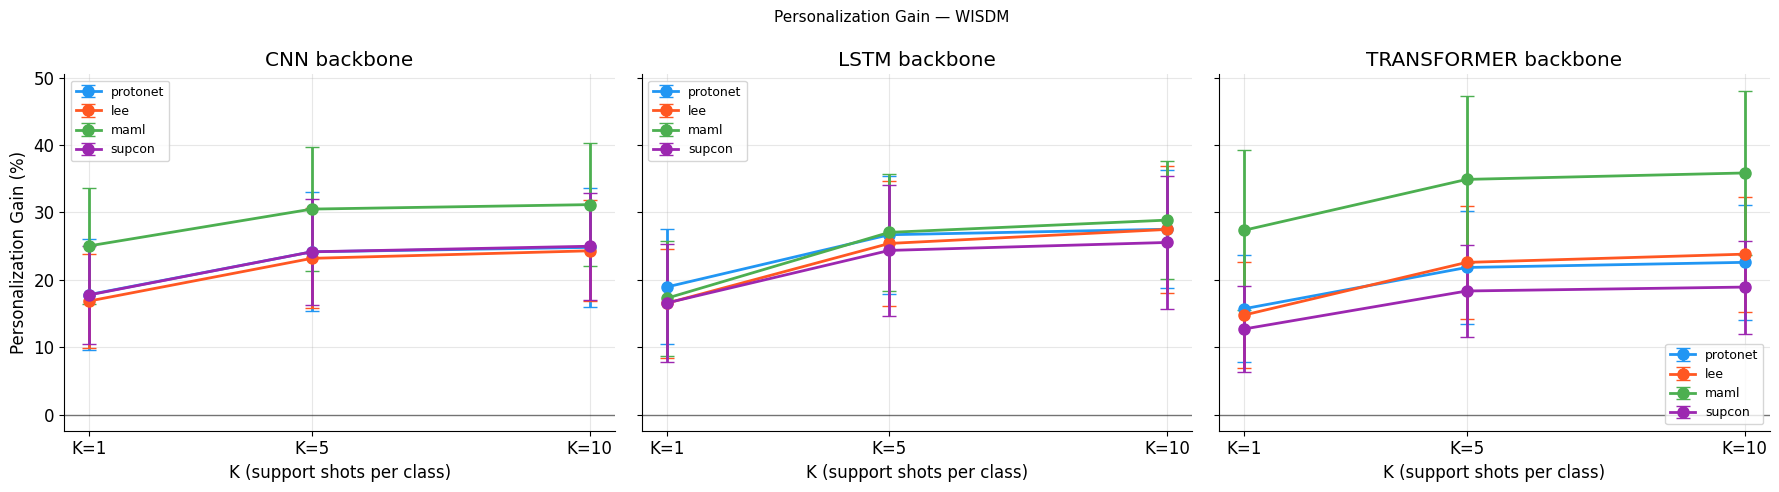

Saved: /content/drive/MyDrive/fsl_har_results/personalization_wisdm_kshot_curves.png


In [14]:
avail_bb = [b for b in ALL_BACKBONES if b in results_pers]

if avail_bb:
    n_cols = len(avail_bb)

    fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 5), sharey=True)

    if n_cols == 1:
        axes = [axes]

    for ax, bb in zip(axes, avail_bb):

        ax.axhline(y=0, color='black', linewidth=1.0, alpha=0.5)

        for method in ALL_FSL_METHODS:
            ks = sorted(results_pers[bb][method].keys())
            if not ks:
                continue

            gains = [
                np.mean([r['gain'] for r in results_pers[bb][method][k]]) * 100
                for k in ks
            ]

            ci95s = [
                1.96 * np.std([r['gain'] for r in results_pers[bb][method][k]])
                / np.sqrt(len(results_pers[bb][method][k])) * 100
                for k in ks
            ]

            ax.errorbar(
                ks,
                gains,
                yerr=ci95s,
                label=method,
                color=METHOD_COLORS.get(method, 'gray'),
                marker='o',
                linewidth=2,
                markersize=8,
                capsize=5
            )

        ax.set_xticks(K_SHOTS)
        ax.set_xticklabels([f'K={k}' for k in K_SHOTS])
        ax.set_xlabel('K (support shots per class)')

        if bb == avail_bb[0]:
            ax.set_ylabel('Personalization Gain (%)')

        ax.set_title(f'{bb.upper()} backbone')
        ax.legend(fontsize=9)

    fig.suptitle(f'Personalization Gain — {DATASET_NAME.upper()}', fontsize=11)

    plt.tight_layout()

    p = os.path.join(
        RESULTS_BASE,
        f'personalization_{DATASET_NAME}_kshot_curves.png'
    )

    plt.savefig(p, dpi=120, bbox_inches='tight')
    plt.show()

    print(f'Saved: {p}')

## Cell 9 — Per-User Gain Distribution (Boxplots)

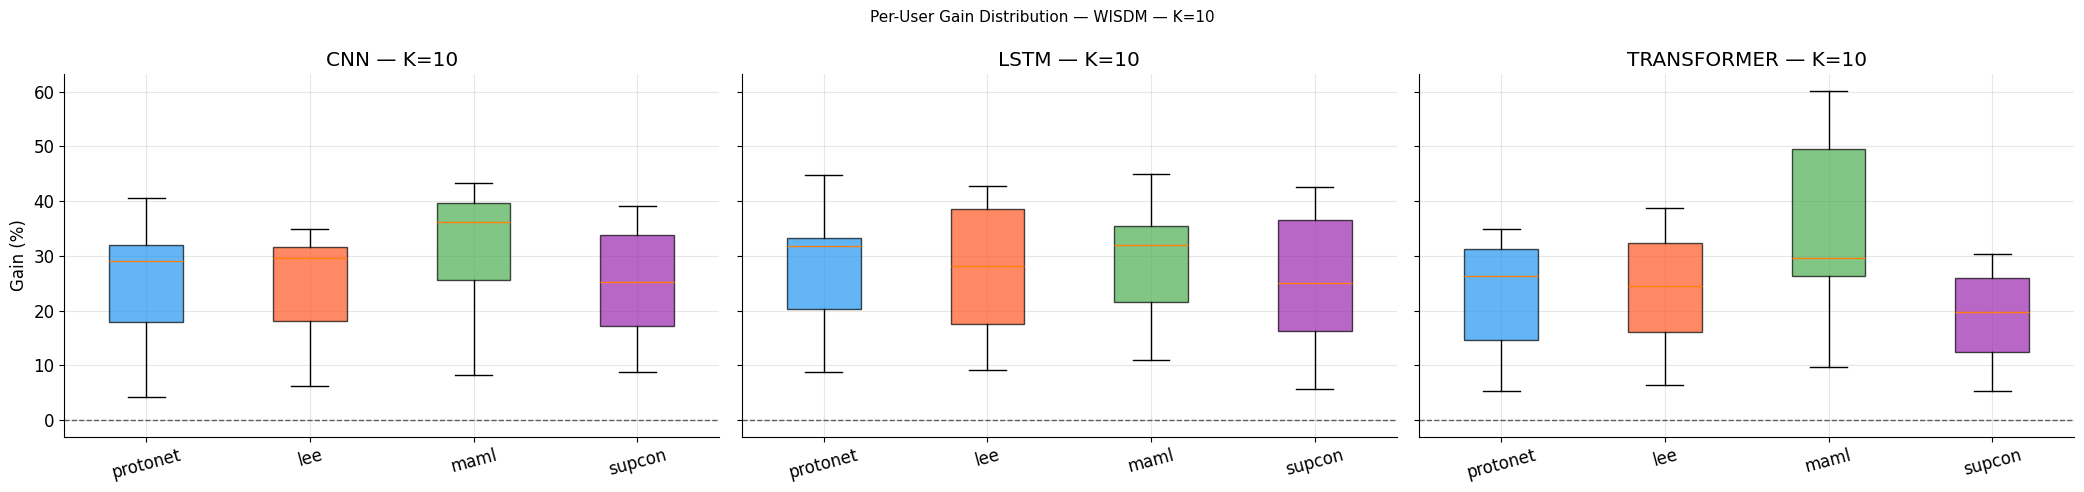

Saved: /content/drive/MyDrive/fsl_har_results/personalization_wisdm_boxplots.png


In [15]:
k_focus = max(K_SHOTS)

avail_bb = [b for b in ALL_BACKBONES if b in results_pers]

if avail_bb:
    fig, axes = plt.subplots(
        1,
        len(avail_bb),
        figsize=(7 * len(avail_bb), 5),
        sharey=True
    )

    if len(avail_bb) == 1:
        axes = [axes]

    for ax, bb in zip(axes, avail_bb):

        plot_data = []
        plot_labels = []
        plot_colors = []

        for method in ALL_FSL_METHODS:
            rows = results_pers[bb][method][k_focus]
            if not rows:
                continue

            plot_data.append([r['gain'] * 100 for r in rows])
            plot_labels.append(method)
            plot_colors.append(METHOD_COLORS.get(method, 'gray'))

        if not plot_data:
            ax.set_title(f'{bb.upper()} — no data')
            continue

        bp = ax.boxplot(
            plot_data,
            labels=plot_labels,
            patch_artist=True,
            showfliers=True
        )

        for patch, color in zip(bp['boxes'], plot_colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        ax.axhline(
            y=0,
            color='black',
            linewidth=1.0,
            linestyle='--',
            alpha=0.6
        )

        ax.set_title(f'{bb.upper()} — K={k_focus}')

        if bb == avail_bb[0]:
            ax.set_ylabel('Gain (%)')

        ax.tick_params(axis='x', rotation=15)

    fig.suptitle(
        f'Per-User Gain Distribution — {DATASET_NAME.upper()} — K={k_focus}',
        fontsize=11
    )

    plt.tight_layout()

    p = os.path.join(
        RESULTS_BASE,
        f'personalization_{DATASET_NAME}_boxplots.png'
    )

    plt.savefig(p, dpi=120, bbox_inches='tight')
    plt.show()

    print(f'Saved: {p}')

## Cell 10 — Personalization Gain Heatmap (Per User × Method)

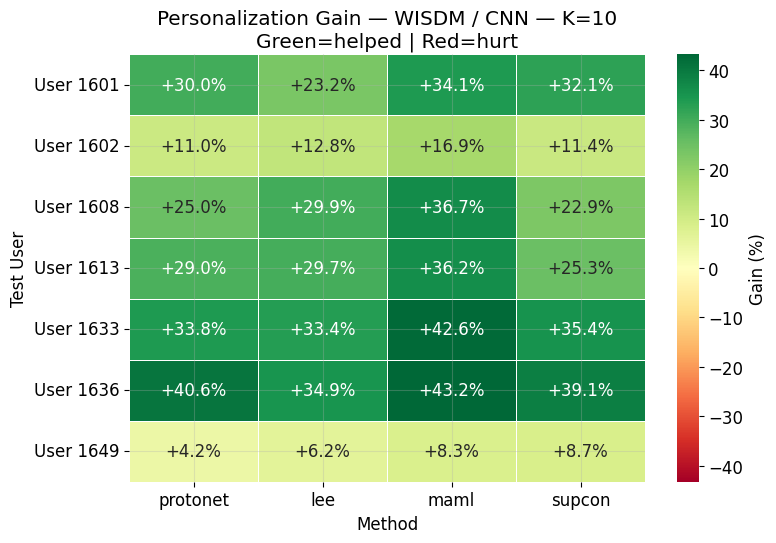

Saved: /content/drive/MyDrive/fsl_har_results/personalization_wisdm_cnn_user_heatmap.png


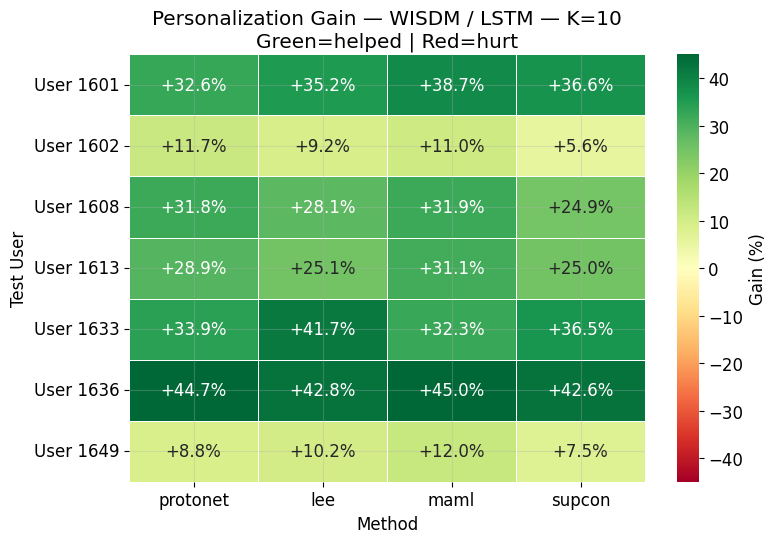

Saved: /content/drive/MyDrive/fsl_har_results/personalization_wisdm_lstm_user_heatmap.png


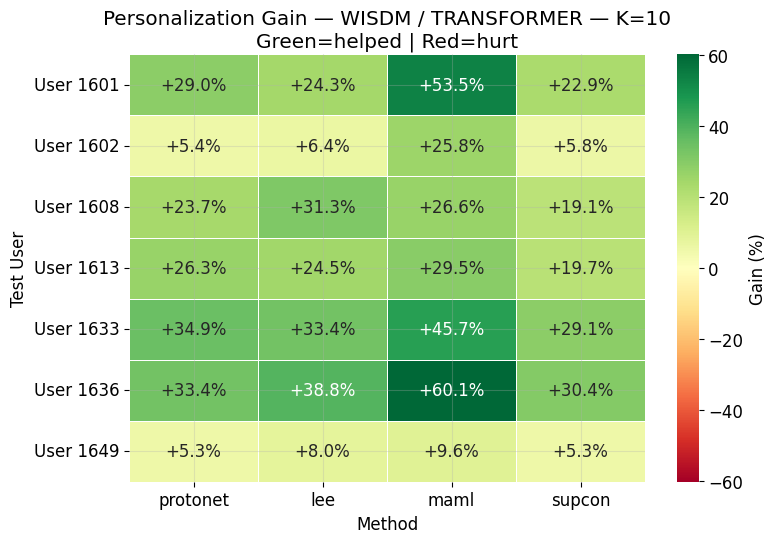

Saved: /content/drive/MyDrive/fsl_har_results/personalization_wisdm_transformer_user_heatmap.png


In [16]:
k_focus = max(K_SHOTS)

avail_bb = [b for b in ALL_BACKBONES if b in results_pers]

for bb in avail_bb:

    users_set = set()
    for method in ALL_FSL_METHODS:
        for r in results_pers[bb][method][k_focus]:
            users_set.add(str(r['subject']))

    if not users_set:
        continue

    users_sorted = sorted(users_set)

    methods_avail = [
        m for m in ALL_FSL_METHODS
        if results_pers[bb][m][k_focus]
    ]

    if not methods_avail:
        continue

    matrix = np.full((len(users_sorted), len(methods_avail)), np.nan)

    for j, method in enumerate(methods_avail):
        for r in results_pers[bb][method][k_focus]:
            try:
                i = users_sorted.index(str(r['subject']))
                matrix[i, j] = r['gain'] * 100
            except ValueError:
                pass

    if np.all(np.isnan(matrix)):
        continue

    fig, ax = plt.subplots(
        figsize=(
            max(5, len(methods_avail) * 2),
            max(4, len(users_sorted) * 0.8)
        )
    )

    vabs = np.nanmax(np.abs(matrix))

    annot = np.where(
        np.isnan(matrix),
        '—',
        np.vectorize(lambda x: f'{x:+.1f}%')(matrix)
    )

    sns.heatmap(
        np.nan_to_num(matrix),
        xticklabels=methods_avail,
        yticklabels=[f'User {u}' for u in users_sorted],
        annot=annot,
        fmt='',
        cmap='RdYlGn',
        center=0,
        vmin=-vabs,
        vmax=vabs,
        linewidths=0.5,
        ax=ax,
        cbar_kws={'label': 'Gain (%)'}
    )

    ax.set_title(
        f'Personalization Gain — {DATASET_NAME.upper()} / {bb.upper()} — K={k_focus}\n'
        f'Green=helped | Red=hurt'
    )

    ax.set_xlabel('Method')
    ax.set_ylabel('Test User')

    plt.tight_layout()

    p = os.path.join(
        RESULTS_BASE,
        f'personalization_{DATASET_NAME}_{bb}_user_heatmap.png'
    )

    plt.savefig(p, dpi=120, bbox_inches='tight')
    plt.show()

    print(f'Saved: {p}')

## Cell 11 — Consistency Analysis

In [17]:
k_focus = max(K_SHOTS)

print(f'── Personalization Consistency (K={k_focus}-shot) ──\n')

print(
    f'{"Method":<12} {"Backbone":<12} {"Users helped":>14} '
    f'{"Mean gain":>12} {"Gain (helped)":>15} {"Gain (hurt)":>13}'
)

print('─' * 82)

for method in ALL_FSL_METHODS:
    for bb in ALL_BACKBONES:

        rows = results_pers[bb][method][k_focus]
        if not rows:
            continue

        gains = np.array([r['gain'] for r in rows])

        n_pos   = (gains > 0).sum()
        n_total = len(gains)

        mean_g = gains.mean()

        mean_helped = gains[gains > 0].mean() if n_pos > 0 else 0.0
        mean_hurt   = gains[gains < 0].mean() if (gains < 0).sum() > 0 else 0.0

        print(
            f'{method:<12} {bb:<12} '
            f'{n_pos}/{n_total} ({n_pos/n_total*100:.0f}%){"":>5} '
            f'{mean_g*100:>+10.2f}% '
            f'{mean_helped*100:>+13.2f}% '
            f'{mean_hurt*100:>+11.2f}%'
        )

print()
print('Interpretation:')
print('  100% users helped + large mean = method works reliably for all users')
print('  Some users hurt = method is user-dependent or K too low')

── Personalization Consistency (K=10-shot) ──

Method       Backbone       Users helped    Mean gain   Gain (helped)   Gain (hurt)
──────────────────────────────────────────────────────────────────────────────────
protonet     cnn          7/7 (100%)          +24.80%        +24.80%       +0.00%
protonet     lstm         7/7 (100%)          +27.50%        +27.50%       +0.00%
protonet     transformer  7/7 (100%)          +22.58%        +22.58%       +0.00%
lee          cnn          7/7 (100%)          +24.29%        +24.29%       +0.00%
lee          lstm         7/7 (100%)          +27.47%        +27.47%       +0.00%
lee          transformer  7/7 (100%)          +23.80%        +23.80%       +0.00%
maml         cnn          7/7 (100%)          +31.15%        +31.15%       +0.00%
maml         lstm         7/7 (100%)          +28.85%        +28.85%       +0.00%
maml         transformer  7/7 (100%)          +35.84%        +35.84%       +0.00%
supcon       cnn          7/7 (100%)          +2

## Cell 12 — Generalization vs Personalization Trade-off

── Gen Acc vs Pers Gain (K=10) ──
Method       Backbone        Gen Acc    Pers Gain
──────────────────────────────────────────────────
protonet     cnn             88.51%     +24.80%
protonet     cnn             88.51%     +24.80%
protonet     lstm            87.08%     +27.50%
supcon       cnn             86.88%     +24.97%
supcon       cnn             86.88%     +24.97%
protonet     transformer     86.61%     +22.58%
supcon       lstm            86.37%     +25.53%
supcon       transformer     84.97%     +18.91%
maml         cnn             83.28%     +31.15%
maml         cnn             83.28%     +31.15%
maml         lstm            81.31%     +28.85%
maml         transformer     81.22%     +35.84%
protonet     transformer      1.18%     +22.58%
protonet     lstm             1.08%     +27.50%


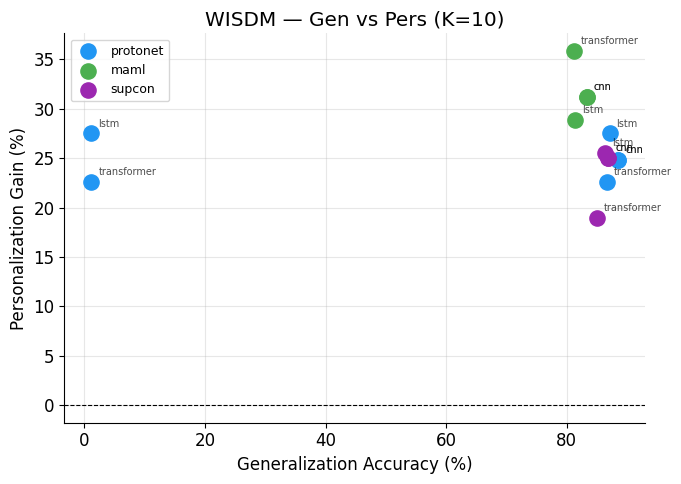

Saved: /content/drive/MyDrive/fsl_har_results/gen_vs_pers_wisdm_scatter.png


In [18]:
gen_csv  = os.path.join(RESULTS_BASE, f'generalization_{DATASET_NAME}.csv')
pers_csv = os.path.join(RESULTS_BASE, f'personalization_{DATASET_NAME}.csv')

if not os.path.exists(gen_csv):
    print('Run notebook 12 first to generate generalization results')

elif not os.path.exists(pers_csv):
    print('Personalization CSV not yet written')

else:
    df_gen  = pd.read_csv(gen_csv)
    df_pers = pd.read_csv(pers_csv)

    k_focus = max(K_SHOTS)

    df_gen_k = (
        df_gen[df_gen['k_shot'] == k_focus][['method', 'backbone', 'acc_mean']]
        .rename(columns={'acc_mean': 'gen_acc'})
    )

    df_pers_k = (
        df_pers[df_pers['k_shot'] == k_focus]
        .groupby(['method', 'backbone'])['gain']
        .mean()
        .reset_index()
        .rename(columns={'gain': 'pers_gain'})
    )

    df_merged = pd.merge(
        df_gen_k,
        df_pers_k,
        on=['method', 'backbone'],
        how='inner'
    )

    if df_merged.empty:
        print('No overlap — check method names match between notebooks 12 and 13')

    else:
        print(f'── Gen Acc vs Pers Gain (K={k_focus}) ──')
        print(f'{"Method":<12} {"Backbone":<12} {"Gen Acc":>10} {"Pers Gain":>12}')
        print('─' * 50)

        for _, r in df_merged.sort_values('gen_acc', ascending=False).iterrows():
            print(
                f'{r["method"]:<12} {r["backbone"]:<12} '
                f'{r["gen_acc"]*100:>8.2f}% {r["pers_gain"]*100:>+10.2f}%'
            )

        fig, ax = plt.subplots(figsize=(7, 5))

        for method in ALL_FSL_METHODS:
            sub = df_merged[df_merged['method'] == method]
            if sub.empty:
                continue

            ax.scatter(
                sub['gen_acc'] * 100,
                sub['pers_gain'] * 100,
                color=METHOD_COLORS.get(method, 'gray'),
                label=method,
                s=120,
                zorder=3
            )

            for _, r in sub.iterrows():
                ax.annotate(
                    r['backbone'],
                    (r['gen_acc'] * 100, r['pers_gain'] * 100),
                    fontsize=7,
                    alpha=0.7,
                    textcoords='offset points',
                    xytext=(5, 5)
                )

        ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')

        ax.set_xlabel('Generalization Accuracy (%)')
        ax.set_ylabel('Personalization Gain (%)')

        ax.set_title(f'{DATASET_NAME.upper()} — Gen vs Pers (K={k_focus})')
        ax.legend(fontsize=9)

        plt.tight_layout()

        p = os.path.join(
            RESULTS_BASE,
            f'gen_vs_pers_{DATASET_NAME}_scatter.png'
        )

        plt.savefig(p, dpi=120, bbox_inches='tight')
        plt.show()

        print(f'Saved: {p}')

## Cell 13 — Final Summary

In [19]:
print('=' * 65)
print('  PERSONALIZATION EVALUATION COMPLETE')
print('=' * 65)

print(f'  Dataset       : {DATASET_NAME}')
print(f'  Test users    : {len(user_data)}')
print(f'  K values      : {K_SHOTS}')
print(f'  Trials/user/K : {N_TRIALS}')
print()

k_focus = max(K_SHOTS)
best = None

for bb in ALL_BACKBONES:
    for method in ALL_FSL_METHODS:
        rows = results_pers[bb][method][k_focus]
        if not rows:
            continue

        mg = np.mean([r['gain'] for r in rows])

        if best is None or mg > best[2]:
            best = (bb, method, mg)

if best:
    print(
        f'  Best config (K={k_focus}): '
        f'{best[0]} + {best[1]} → gain = {best[2]*100:+.2f}%'
    )

print()
print(f'  Results saved to: {RESULTS_BASE}')
print('=' * 65)
print()
print('  Phase 2 complete for this dataset.')
print('  → Change DATASET_NAME to repeat for other datasets')
print('  → Notebook 15 (results analysis) reads all CSVs together')
print('=' * 65)

  PERSONALIZATION EVALUATION COMPLETE
  Dataset       : wisdm
  Test users    : 7
  K values      : [1, 5, 10]
  Trials/user/K : 10

  Best config (K=10): transformer + maml → gain = +35.84%

  Results saved to: /content/drive/MyDrive/fsl_har_results

  Phase 2 complete for this dataset.
  → Change DATASET_NAME to repeat for other datasets
  → Notebook 15 (results analysis) reads all CSVs together
